In [1]:
from spectral_core import (
    SpectralDataset,
    PreprocessingPipeline, 
    SavitzkyGolayFilter, 
    Normalization, 
    RegionSelector, 
    SampleFilter,
    DataSplitter,
    BaselineCorrection
)
from spectral_core.curvefit.curvefit import SpectraFit

/home/mykola/.cache/pypoetry/virtualenvs/spectral-core-S9wPqFE3-py3.13/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np

In [3]:
dataset = SpectralDataset.from_csv(
    file_path='../data/dataset_681.csv',
    wavenumbers_path='../data/wavenumbers.csv',
)

In [4]:
dataset.summary()

### Spectral Dataset Summary
- **Samples:** 681
- **Features:** 7467 wavenumbers
- **Range:** 400.6 - 4000.2 cm⁻¹

,Mean,Std,Min,Max
HbA1c,7.366579,2.443136,3.57,17.06
Age,57.944200,15.904814,0.00,92.00


In [5]:
pipeline = PreprocessingPipeline([
    SampleFilter(feature_max={"HbA1c": 14.0}, exclude_indices=[287, 636]),
    SavitzkyGolayFilter(window_length=5, polyorder=3),
    Normalization(method='amide', margin=700),
    BaselineCorrection(),
    RegionSelector(regions=[(1000, 1720)])
])

preprocessed_data = pipeline.apply(dataset)

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Spectra colored by HbA1c'}, xlabel='Wavenumbers (cm⁻¹)', ylabel='Absorbance'>)

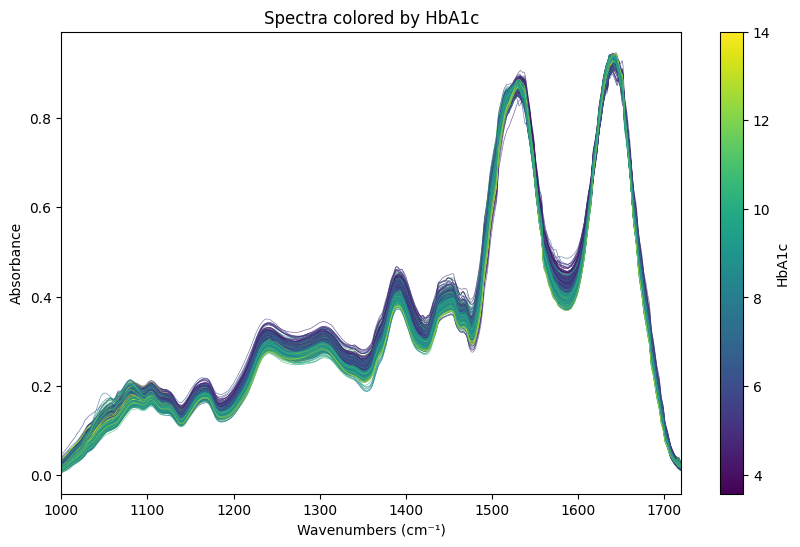

In [6]:
preprocessed_data.plot_spectra(feature='HbA1c', figsize=(10, 6))

In [7]:
preprocessed_data[0].spectra[0]

array([0.01569385, 0.01612954, 0.01656618, ..., 0.02058174, 0.01979239,
       0.01917367], shape=(1493,))

In [8]:
y_values = preprocessed_data[0].spectra[0]
x_values = preprocessed_data.wavenumbers
peaks = pd.read_csv('/home/mykola/projects/ftir-hba1c-prediction/data/peaks_56.csv').to_numpy()

params = {
    "center": {"min": 3, "max": 3},
    "fwhm": {"value": 3},
    "eta": {"value": 0.5}
}

pmodel = SpectraFit()
pmodel.fit(x_values, y_values, peaks, param_dict=params, ftol=1e-12)

,wavenumber,FWHM,amplitude,eta,height,area,area_abs
0,1014.495639,14.279749,0.197846,9.999990e-01,0.013014,0.000796,0.195843
1,1030.031151,18.934524,0.707414,7.909505e-01,0.032721,0.002812,0.692141
2,1043.005176,7.074540,0.025861,6.571810e-01,0.003049,0.000104,0.025612
3,1051.608346,28.998630,2.389580,9.595955e-01,0.076402,0.009670,2.380394
4,1080.912886,32.015633,3.928742,1.000000e+00,0.115281,0.015960,3.928742
5,1106.593309,25.847945,3.946563,2.001713e-01,0.106448,0.015452,3.803693
6,1125.677219,19.009538,1.120862,1.000000e+00,0.055389,0.004553,1.120862
7,1159.396277,43.189796,7.706006,8.536175e-32,0.113584,0.029575,7.280375
8,1170.963297,11.053804,0.229896,1.000000e+00,0.019532,0.000934,0.229896
9,1235.793000,54.140375,12.359013,8.080109e-32,0.145323,0.047483,11.688740


In [9]:
fig = pmodel.plot_fit_plotly()
fig.show()
print(pmodel.r2, pmodel.discrepancy)

0.9999828962484231 0.0009545504632539855


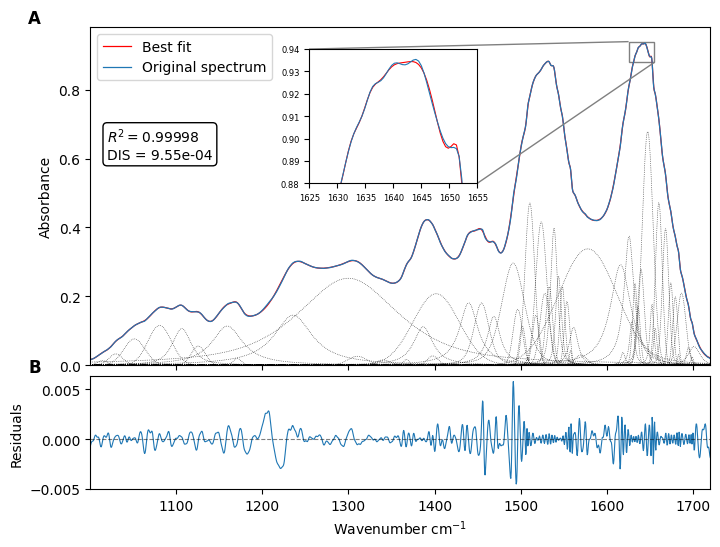

In [49]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def make_combined_plot(pmodel):
    """ Plots fit (top) and residuals (bottom) share x-axis """
    
    x_values = pmodel.x_values
    y_values = pmodel.y_values
    
    fig, (ax_main, ax_res) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(8, 6), 
        sharex=True, 
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
    )

    y_peaks = []
    
    for index, row in pmodel.params.iterrows():
        ff = SpectraFit()
        y_pred = ff.combined_pseudo_voigt(x_values, *row[['wavenumber', 'FWHM', 'amplitude', 'eta']], 0)
        ax_main.plot(x_values, y_pred, color='k', linewidth=0.5, linestyle=':', alpha=0.8)
        y_peaks.append(y_pred)
    
    y_peaks = np.array(y_peaks)
    y_fit = y_peaks.sum(axis=0)

    ax_main.plot(x_values, y_fit, color='r', linewidth=0.9, label='Best fit')
    ax_main.plot(x_values, y_values, linewidth=0.9, label='Original spectrum')
    ax_main.set_ylabel("Absorbance")
    ax_main.legend()
    
    axins = zoomed_inset_axes(ax_main, 6.5, loc='upper left', bbox_to_anchor=(0.39, 0.455, 0.25, 0.4), bbox_transform=fig.transFigure)
    axins.plot(x_values, y_fit, color='r', linewidth=0.8)
    axins.plot(x_values, y_values, linewidth=0.8)
    
    x1, x2 = 1625, 1655
    y1, y2 = 0.88, 0.94
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.tick_params(axis='both', which='both', labelsize=6)
    
    mark_inset(ax_main, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    text = f"$R^2 = {pmodel.r2:.5f}$\nDIS = {pmodel.discrepancy:.2e}"
    ax_main.text(
        1020, 0.6, text, 
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.3')
    )
    
    residuals = y_values - y_fit
    ax_res.plot(x_values, residuals, linewidth=0.8)
    ax_res.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax_res.set_ylabel("Residuals")
    ax_res.set_xlabel("Wavenumber cm$^{-1}$")
    
    ax_main.set_xlim([min(x_values), max(x_values)])
    ax_main.set_ylim(bottom=0.000)

    ax_main.text(-0.08, 1.0, 'A', transform=ax_main.transAxes, 
                 fontsize=12, fontweight='bold', va='bottom', ha='right')

    ax_res.text(-0.08, 1.0, 'B', transform=ax_res.transAxes, 
                fontsize=12, fontweight='bold', va='bottom', ha='right')
    
    return fig, (ax_main, ax_res)

make_combined_plot(pmodel)
plt.savefig('../data/figures/curvefit_plot.png', dpi=800, bbox_inches='tight')